In [1]:
# ReACTEmu Boost Validation Plot
# Author: CLOE Team

import numpy as np
import matplotlib.pyplot as plt

from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations
from cloelib.cosmology.reactemu_cosmology import MGemuNonlinearBoost

/Users/s2265800/miniforge3/envs/mgl_ccl_cloe_env/lib/python3.11/site-packages/MGEmu


In [2]:
# Define validation configuration
validation_config = {
    "fr": {
        "mgparam": 1e-5,
        "file": "validation_data/fR_validation_data.dat"
    },
    "dgp": {
        "mgparam": 0.1,
        "file": "validation_data/dgp_validation_data.dat"
    }
}

# Redshifts and their corresponding column indices in the data files
redshifts = [0.1, 0.478, 0.785, 1.5]
z_cols = {0.1: 4, 0.478: 3, 0.785: 2, 1.5: 1}

# Shared CAMB background (from validation cosmology)
camb = CAMBBackground(
    H0=67.39774575153639,
    Omega_b0=0.05062684354655124,
    Omega_cdm0=0.3164470361777248 - 0.05062684354655124,
    Omega_k0=0.0,
    As=2.1977194699875245e-9,
    ns=0.9423180532642602,
    mnu=0.0,
    w0=-1,
    wa=0,
    gamma_MG=0.0,
)

linear = CAMBLinearPerturbations(camb, np.array(redshifts))

Note: redshifts have been re-sorted (earliest first)



📊 Plotting boost comparison for model: fr


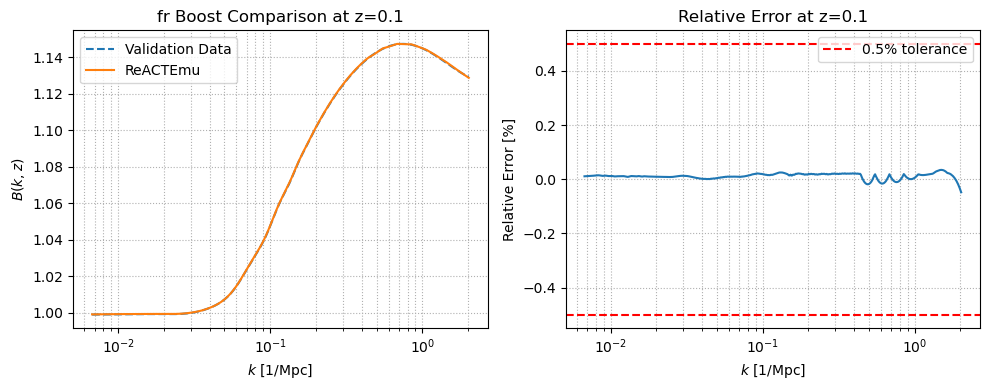

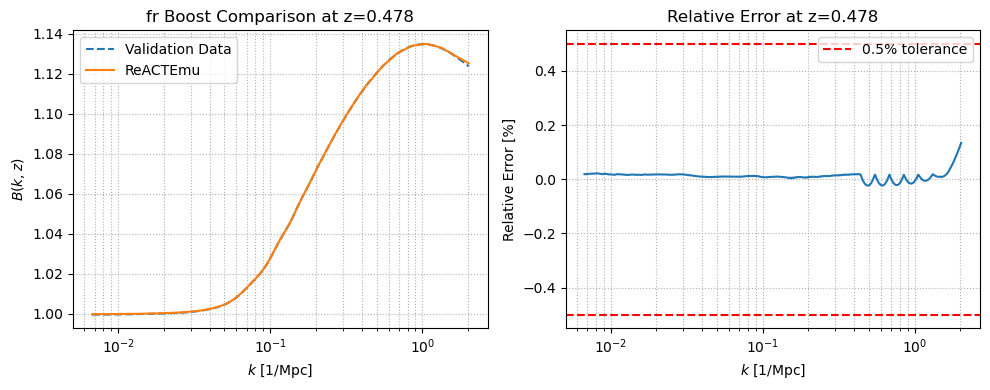

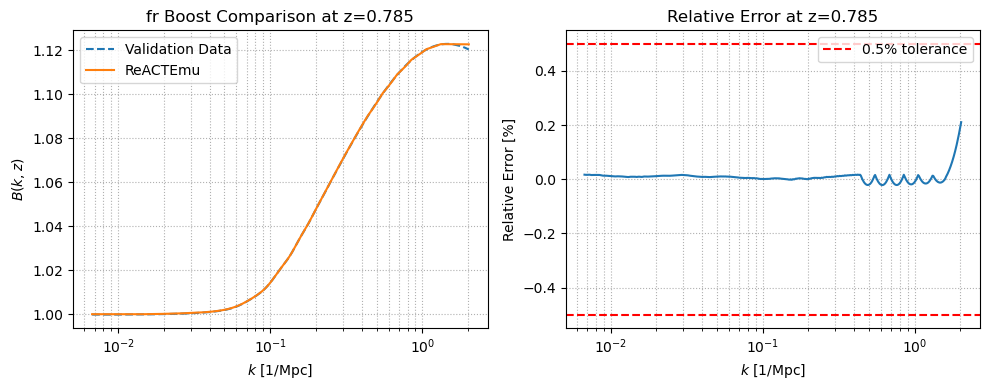

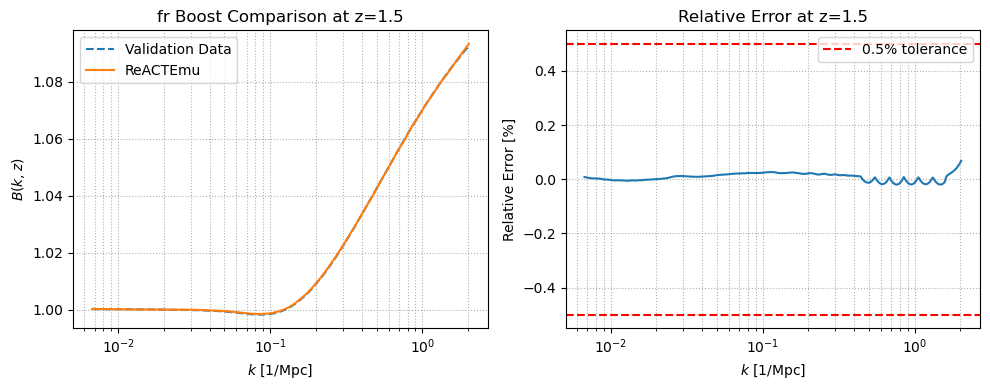


📊 Plotting boost comparison for model: dgp


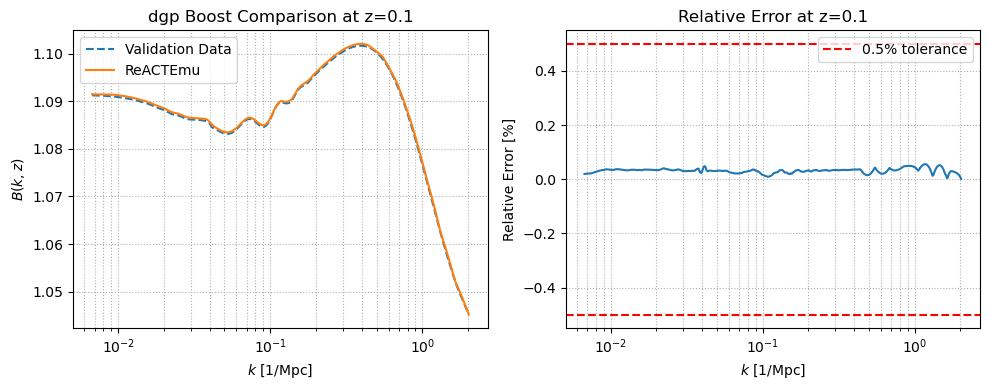

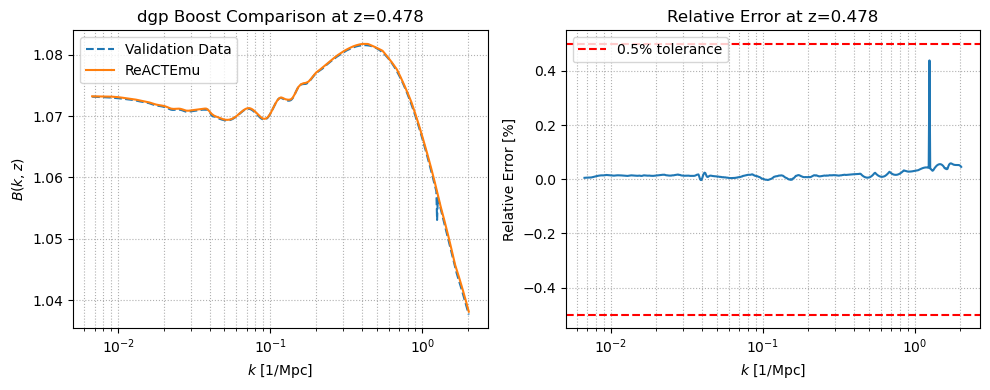

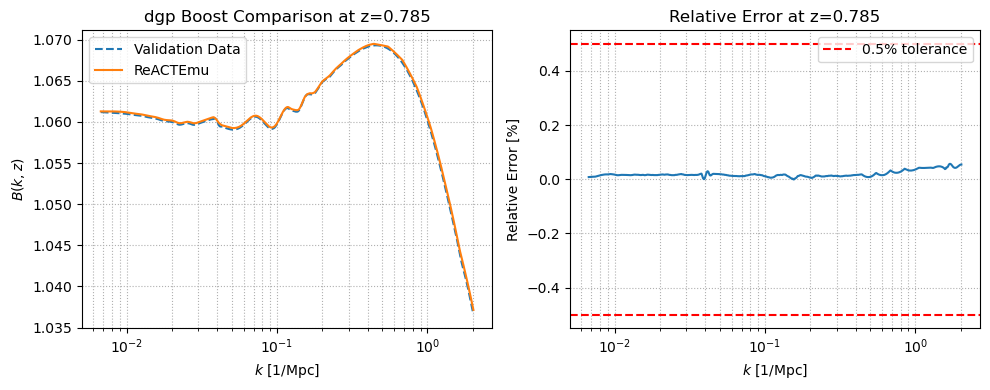

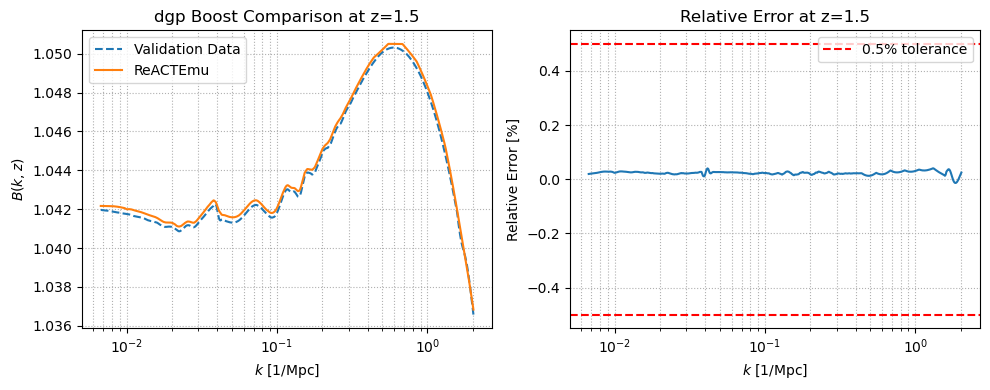

In [3]:
mgparam_dic = {'fr0': validation_config["fr"]["mgparam"], 'omega_rc':validation_config["dgp"]["mgparam"]}
# Loop through each model
for model, cfg in validation_config.items():
    mgparam = cfg["mgparam"]
    filepath = cfg["file"]

    print(f"\n📊 Plotting boost comparison for model: {model}")

    # Load data
    data = np.loadtxt(filepath)
    k_vals = data[:, 0] * camb.H0/100  # Convert from h/Mpc to 1/Mpc

    # Compute emulator boost
    emu = MGemuNonlinearBoost(camb, linear, np.array(redshifts), gravity_model=model, mgpars=mgparam_dic)
    interp = emu.MGboost_interp

    # Plot for each z
    for z in redshifts:
        B_model = interp(z, k_vals, grid=False)
        B_data = data[:, z_cols[z]]

        rel_err = 100 * (B_model - B_data) / B_data

        plt.figure(figsize=(10, 4))

        # Absolute comparison
        plt.subplot(1, 2, 1)
        plt.title(f"{model} Boost Comparison at z={z}")
        plt.plot(k_vals, B_data, label="Validation Data", linestyle="dashed")
        plt.plot(k_vals, B_model, label="ReACTEmu", linestyle="solid")
        plt.xlabel(r"$k$ [1/Mpc]")
        plt.ylabel(r"$B(k,z)$")
        plt.xscale("log")
        plt.legend()
        plt.grid(True, which="both", linestyle=":")

        # Relative error
        plt.subplot(1, 2, 2)
        plt.title(f"Relative Error at z={z}")
        plt.plot(k_vals, rel_err)
        plt.axhline(0.5, color='r', linestyle='--', label="0.5% tolerance")
        plt.axhline(-0.5, color='r', linestyle='--')
        plt.xlabel(r"$k$ [1/Mpc]")
        plt.ylabel(r"Relative Error [%]")
        plt.xscale("log")
        plt.grid(True, which="both", linestyle=":")
        plt.legend()

        plt.tight_layout()
        plt.show()

## Test extrapolation

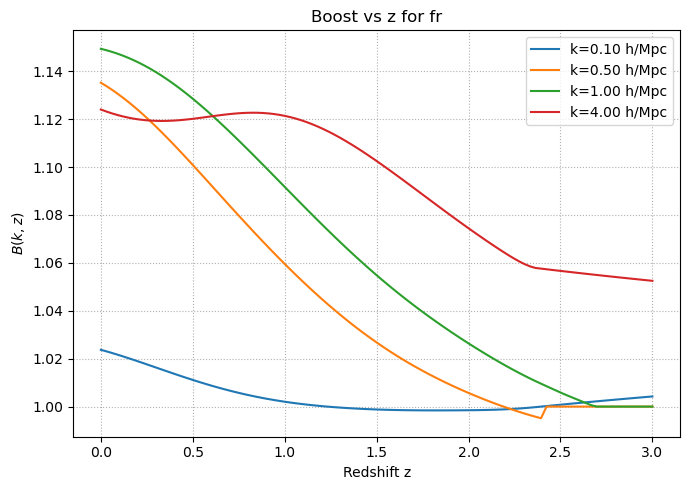

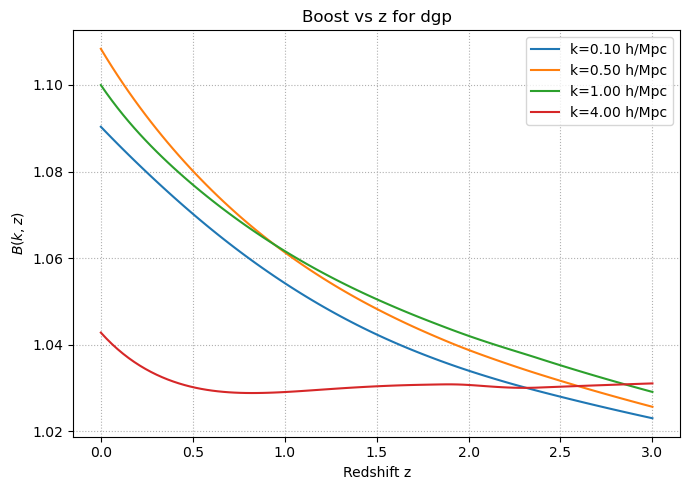

In [4]:
# 🚀 Plot boost as a function of redshift for fixed k
k_vals_z = [0.1 * camb.H0/100, 0.5 * camb.H0/100, 1.0 * camb.H0/100, 4.0 * camb.H0/100]  # [1/Mpc]
z_range = np.linspace(0, 3, 100)

for model, cfg in validation_config.items():
    mgparam = cfg["mgparam"]

    emu = MGemuNonlinearBoost(camb, linear, z_range, model, mgparam_dic)
    interp = emu.MGboost_interp

    plt.figure(figsize=(7, 5))
    plt.title(f"Boost vs z for {model}")

    for k in k_vals_z:
        boost = interp(z_range, k, grid=False)
        plt.plot(z_range, boost, label=f"k={k*100/camb.H0:.2f} h/Mpc")

    plt.xlabel("Redshift z")
    plt.ylabel(r"$B(k, z)$")
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

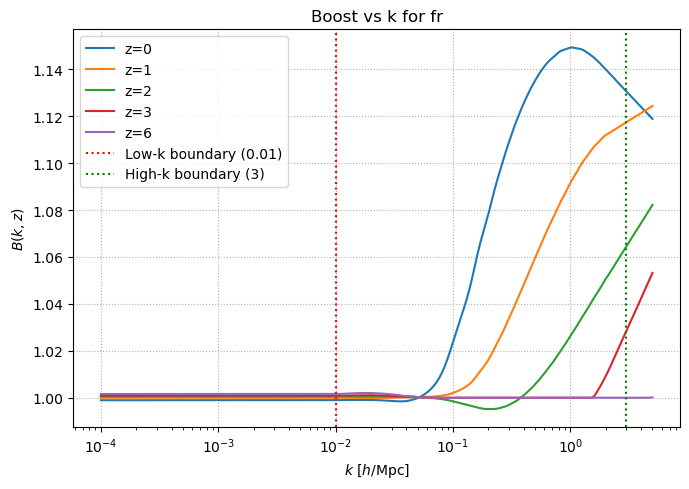

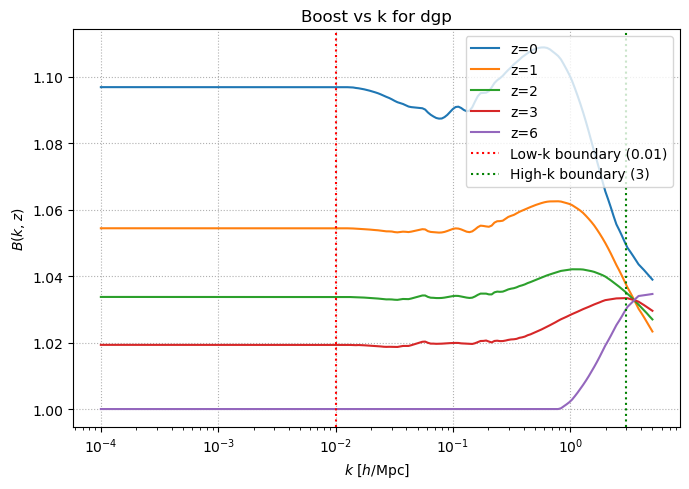

/Users/s2265800/miniforge3/envs/mgl_ccl_cloe_env/lib/python3.11/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


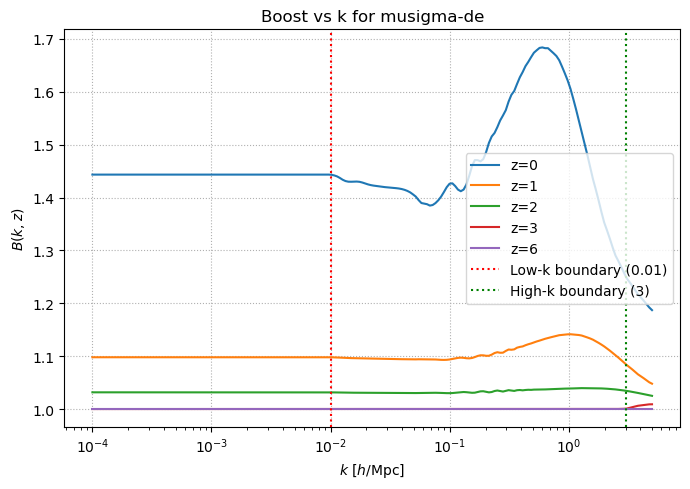

In [5]:
# 🚀 Plot boost as a function of k for fixed z
k_range = np.logspace(np.log10(0.0001), np.log10(5), 200) * camb.H0/100  # [1/Mpc]
z_vals_k = np.array([0, 1, 2, 3, 6])

config_new = {
    "fr": {
        "mgparam": 1e-5,
    },
    "dgp": {
        "mgparam": 0.1,
    },
    "musigma-de": {
        "mgparam": [1.5, 0., 0.8],
    }
}
mgparam_dic_new = {'fr0': config_new["fr"]["mgparam"], 'omega_rc':config_new["dgp"]["mgparam"],
               'mu0':config_new["musigma-de"]["mgparam"][0], 'sigma0':config_new["musigma-de"]["mgparam"][1], 
               'q1':config_new["musigma-de"]["mgparam"][2]}

for model, cfg in config_new.items():
    mgparam = cfg["mgparam"]

    emu = MGemuNonlinearBoost(camb, linear, z_vals_k, model, mgparam_dic_new)
    interp = emu.MGboost_interp

    plt.figure(figsize=(7, 5))
    plt.title(f"Boost vs k for {model}")

    for z in z_vals_k:
        boost = interp(z, k_range, grid=False)
        plt.plot(k_range * 100 / camb.H0, boost, label=f"z={z}")

    plt.axvline(0.01, color='red', linestyle='dotted', label="Low-k boundary (0.01)")
    plt.axvline(3.0, color='green', linestyle='dotted', label="High-k boundary (3)")

    plt.xlabel(r"$k$ [$h$/Mpc]")
    plt.ylabel(r"$B(k, z)$")
    plt.xscale("log")
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()